# 实验 12：用于连续控制的深度确定性策略梯度（DDPG）

在本实验中，你将实现并训练一个 **深度确定性策略梯度（Deep Deterministic Policy Gradient, DDPG）** 智能体，用于求解一个基于 MuJoCo 物理仿真器的 **连续控制任务**。

本实验使用的目标环境为：

> **Hopper-v4** —— 一个单腿机器人，需要学习如何尽可能快速且稳定地向前跳跃。

## 1. 环境：Hopper-v4

[Hopper 环境](https://gymnasium.farama.org/environments/mujoco/hopper/) 是一个基于 **MuJoCo** 仿真的物理运动控制任务。

- **观测空间：** 11 维连续状态
- **动作空间：** 3 维连续力矩控制
- **目标：** 在不摔倒的前提下尽可能快速地向前移动
- **回合结束条件：** 机器人摔倒或变得不稳定

这个任务代表了一类较为真实的机器人控制问题，具有以下特点：

- 非线性动力学
- 高维状态空间
- 连续动作
- 长期信用分配问题

In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

env = gym.make("Hopper-v4", render_mode="rgb_array")
print("Env id:", env.spec.id)  
obs, info = env.reset(seed=0)

frames = []
num_steps = 300

for t in range(num_steps):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)

    frame = env.render()
    frames.append(frame.copy())   

    if terminated or truncated:
        obs, info = env.reset()

env.close()
print("Collected frames:", len(frames))

def show_frame(i):
    plt.figure(figsize=(4, 4))
    plt.imshow(frames[i])
    plt.axis("off")
    plt.title(f"Hopper-v4 frame {i}")
    plt.show()

interact(
    show_frame,
    i=IntSlider(0, min=0, max=len(frames)-1, step=1, description="Frame")
)

Env id: Hopper-v4
Collected frames: 300


interactive(children=(IntSlider(value=0, description='Frame', max=299), Output()), _dom_classes=('widget-inter…

<function __main__.show_frame(i)>

## 2. 背景

许多真实世界中的控制问题都涉及 **连续动作**，例如：

- 机器人关节力矩
- 车辆转向和加速度控制
- 物理系统中的控制力

经典的深度 Q 网络（Deep Q-Network, DQN）不能直接应用于这类问题，因为 DQN 要求动作空间是 **离散的**。

DDPG 通过结合以下几个核心组件，将 Q-learning 扩展到了 **连续控制** 问题：

- 一个 **策略网络（Actor）**，用于输出连续动作。
- 一个 **价值网络（Critic）**，用于估计 Q 函数。
- **目标网络（Target Networks）**，用于提高训练稳定性。
- 一个 **经验回放池（Replay Buffer）**，用于进行离策略学习。

DDPG 是连续动作强化学习中的基础算法之一，也是更高级方法如 **TD3** 和 **SAC** 的重要基础。

## 3. 算法实现：DDPG

DDPG 包含以下几个组成部分：

- **Actor 网络**  
  给定一个状态，输出一个确定性的连续动作。

- **Critic 网络**  
  估计状态-动作对的 Q 值。

- **目标网络（Target Networks）**  
  Actor 和 Critic 的缓慢更新副本，用于提高学习过程的稳定性。

- **经验回放池（Replay Buffer）**  
  存储过去的状态转移样本，用于离策略训练。

- **探索噪声（Exploration Noise）**  
  在训练过程中加入到 Actor 输出的动作上，以保证足够的探索。

In [ ]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import time

## Actor 和 Critic 网络实现提示

### Actor 网络（策略网络）

- **Actor 将状态映射为一个连续动作**。
- 它的输入维度必须与 **观测空间维度** 一致。
- 它的输出维度必须与 **动作空间维度** 一致。
- 使用带有 ReLU 激活函数的 **全连接层**。
- 由于动作必须位于一个 **有界的连续范围** 内，**最后一层应使用 `tanh`**。
- 输出结果必须根据环境的 **最大动作值** 进行缩放。

In [4]:
class Actor(nn.Module):
    def __init__(self, obs_dim, act_dim, max_action):
        super().__init__()
        self.net = nn.Sequential(
             # your time to work on it 
        )
        self.max_action = max_action

    def forward(self, x):
        return self.max_action * self.net(x)

### Critic 网络（Q 函数）

- **Critic 用于估计 Q(s, a)**。
- 它的输入是 **状态向量和动作向量的拼接**。
- 输出是一个 **单一的标量值**，即 Q 值。
- 第一层线性层的输入维度应为：

In [8]:
class Critic(nn.Module):
    def __init__(self, obs_dim, act_dim):
        super().__init__()
        self.net = nn.Sequential(
            # your time to work on it 
        )

    def forward(self, s, a):
        return self.net(torch.cat([s, a], dim=1))

In [ ]:
class ReplayBuffer:
    def __init__(self, capacity=1_000_000):
        self.buffer = deque(maxlen=capacity)

    def push(self, s, a, r, s2, d):
        self.buffer.append((s, a, r, s2, d))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, s2, d = map(np.array, zip(*batch))
        return (
            torch.FloatTensor(s),
            torch.FloatTensor(a),
            torch.FloatTensor(r).unsqueeze(1),
            torch.FloatTensor(s2),
            torch.FloatTensor(d).unsqueeze(1),
        )

    def __len__(self):
        return len(self.buffer)

In [5]:
env = gym.make("Hopper-v4")
obs_dim = env.observation_space.shape[0]
act_dim = env.action_space.shape[0]
max_action = float(env.action_space.high[0])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

actor = Actor(obs_dim, act_dim, max_action).to(device)
critic = Critic(obs_dim, act_dim).to(device)
actor_target = Actor(obs_dim, act_dim, max_action).to(device)
critic_target = Critic(obs_dim, act_dim).to(device)

actor_target.load_state_dict(actor.state_dict())
critic_target.load_state_dict(critic.state_dict())

actor_opt = optim.Adam(actor.parameters(), lr=1e-4)
critic_opt = optim.Adam(critic.parameters(), lr=1e-3)

buffer = ReplayBuffer()

gamma = 0.99
tau = 0.005
batch_size = 256
exploration_noise = 0.1

total_steps = 300_000
warmup_steps = 10_000

state, _ = env.reset()
episode_reward = 0
episode_length = 0

In [6]:
SAVE_PATH = "ddpg_hopper_actor_class.pth"

### 四个 DDPG TODO 的实现提示

#### 从当前策略中选择一个 **连续动作**，并加入 **探索噪声**

- 将当前状态 `state` 转换为 PyTorch 张量，放到正确的 device 上，并添加 batch 维度。
- 将状态输入 **Actor 网络**，得到一个确定性的动作。
- 在训练初期，可以先使用 **完全随机动作**，例如 `env.action_space.sample()`。
- 在 warmup 结束后，在 Actor 输出的动作上加入 **高斯噪声**：

$$
  a_{\text{noisy}} = \pi_{\theta}(s) + \mathcal{N}(0, \sigma^2)
$$

- 最后，使用 `np.clip` 将动作裁剪到环境允许的合法范围内。

#### 计算 Critic 的 **Bellman 目标值**

提示：

- 这里要使用 **目标网络**（`actor_target` 和 `critic_target`），而不是主网络。
- 首先，用目标 Actor 得到下一个状态对应的动作：

$$
  a' = \pi_{\theta'}(s')
$$

- 然后，将 `(s', a')` 输入 **目标 Critic**，得到：

$$
  Q_{\phi'}(s', a')
$$

- 目标 Q 值为：

$$
  y = r + \gamma (1 - d)\, Q_{\phi'}(s', a')
$$

其中：

- $ r $ 表示奖励
- $ d $ 表示 done 标志，如果是终止状态则为 1，否则为 0
- $ \gamma $ 表示折扣因子

#### 使用 **MSE 损失** 训练 Critic，使其拟合 Bellman 目标值

提示：

- 你已经有：
  - `q_val = critic(s, a)` → 当前 Critic 的预测值
  - `q_target` → 第 2 步得到的目标值，应被视为常数，不参与梯度计算
- 使用 **均方误差**：

$$
  \mathcal{L}_{\text{critic}} = \frac{1}{N} \sum_i (Q_{\phi}(s_i, a_i) - y_i)^2
$$

- 在 PyTorch 中，可以使用 `nn.MSELoss()`，也可以写成 `(q_val - q_target).pow(2).mean()`。

#### 更新 Actor，使其选择 Critic 认为 **价值更高** 的动作

- 对于 Actor，我们 **不直接使用 reward**。
- 我们希望 **最大化** $ Q(s, \pi_{\theta}(s))$。
- 等价地，可以 **最小化负的 Q 值**：

$$
  \mathcal{L}_{\text{actor}} = -\,\mathbb{E}_s \big[ Q_{\phi}(s, \pi_{\theta}(s)) \big]
$$

- 实现步骤：
  1. 使用当前 Actor 计算动作：`a_pi = actor(s)`
  2. 使用当前 Critic 评估这些动作：`critic(s, a_pi)`
  3. 取该 Q 值的 **负均值** 作为 Actor loss。

In [7]:
episode = 0

for step in range(total_steps):

    state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
    action = actor(state_tensor).cpu().data.numpy().flatten()

    if step < warmup_steps:
        action = env.action_space.sample()
    else:
        action = # 1. Your time to work on it 

    action = np.clip(action, -max_action, max_action)

    # --- step env ---
    next_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

    buffer.push(state, action, reward, next_state, float(done))

    state = next_state
    episode_reward += reward
    episode_length += 1
    
    # --- reset if done ---
    if done:
        print(f"Episode {episode} | Reward: {episode_reward:.1f} | Lenght: {episode_length}")
        state, _ = env.reset()
        episode_reward = 0
        episode_length = 0
        episode += 1

    # --- update ---
    if len(buffer) > batch_size:

        s, a, r, s2, d = buffer.sample(batch_size)
        s = s.to(device)
        a = a.to(device)
        r = r.to(device)
        s2 = s2.to(device)
        d = d.to(device)

        # Critic update
        with torch.no_grad():
            a2 = actor_target(s2)
            q_target = # 2. Your time to work on it 

        q_val = critic(s, a)
        critic_loss = # 3. Your time to work on it  

        critic_opt.zero_grad()
        critic_loss.backward()
        critic_opt.step()

        # Actor update
        actor_loss = # 4. Your time to work on it 

        actor_opt.zero_grad()
        actor_loss.backward()
        actor_opt.step()

        # Target update
        for p, p_t in zip(actor.parameters(), actor_target.parameters()):
            p_t.data.copy_(tau * p.data + (1 - tau) * p_t.data)

        for p, p_t in zip(critic.parameters(), critic_target.parameters()):
            p_t.data.copy_(tau * p.data + (1 - tau) * p_t.data)

    # --- occasionally show progress ---
    if step % 10_000 == 0:
        print(f"Step {step}/{total_steps}")
        torch.save(actor.state_dict(), SAVE_PATH)
        
print("Training finished and model saved!")

Step 0/300000
Episode 0 | Reward: 13.0 | Lenght: 20
Episode 1 | Reward: 13.7 | Lenght: 16
Episode 2 | Reward: 30.8 | Lenght: 31
Episode 3 | Reward: 61.9 | Lenght: 56
Episode 4 | Reward: 11.2 | Lenght: 17
Episode 5 | Reward: 3.3 | Lenght: 16
Episode 6 | Reward: 15.2 | Lenght: 22
Episode 7 | Reward: 12.8 | Lenght: 14
Episode 8 | Reward: 10.8 | Lenght: 15
Episode 9 | Reward: 11.2 | Lenght: 14
Episode 10 | Reward: 6.3 | Lenght: 10
Episode 11 | Reward: 9.3 | Lenght: 14
Episode 12 | Reward: 43.2 | Lenght: 35
Episode 13 | Reward: 40.5 | Lenght: 40
Episode 14 | Reward: 70.9 | Lenght: 58
Episode 15 | Reward: 36.7 | Lenght: 49
Episode 16 | Reward: 15.2 | Lenght: 37


KeyboardInterrupt: 

In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

env = gym.make("Hopper-v4", render_mode="rgb_array")
print("Env id:", env.spec.id)  
obs, info = env.reset(seed=0)

frames = []
num_steps = 300

for t in range(num_steps):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)

    frame = env.render()
    frames.append(frame.copy())   

    if terminated or truncated:
        obs, info = env.reset()

env.close()
print("Collected frames:", len(frames))

def show_frame(i):
    plt.figure(figsize=(4, 4))
    plt.imshow(frames[i])
    plt.axis("off")
    plt.title(f"Hopper-v4 frame {i}")
    plt.show()

interact(
    show_frame,
    i=IntSlider(0, min=0, max=len(frames)-1, step=1, description="Frame")
)

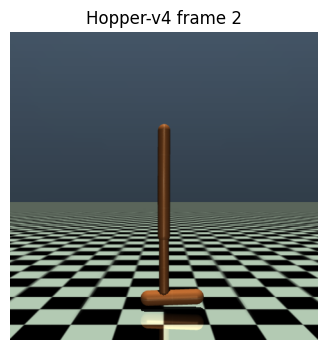